# Introduction to convolutional neural networks and computer vision with TensorFlow and Keras
# https://www.tensorflow.org/tutorials/images/cnn

Computer Vision is the practice of writing algorithms which can discover patterns in visual data. It is a subfield of Artificial Intelligence (AI) and Machine Learning (ML) which focuses on enabling computers to see, identify and process images in a way similar to humans. Convolutional Neural Networks (CNNs) are a class of deep learning models that have proven highly effective for image classification tasks.

## get the data

The image we're working wisth are from the Food-101 dataset. It contains 101 different food categories with 101,000 images. You can find the full dataset on [Kaggle](https://www.kaggle.com/dansbecker/food-101). However we've modified it to only use two classes (pizza and steak) using the image data modification notebook: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

**Note** We start with a smaller dataset so we can experiment quickly. Later on we'll see how to scale this up to larger datasets.

```python
# Download the data (you can also download it manually from Kaggle if you want to see the full dataset)

In [1]:
# import zipfile
# import urllib.request

# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
# zip_path = "pizza_steak.zip"
# urllib.request.urlretrieve(url, zip_path)

# # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()


## Inspect the data (become one with it)

A very crucial step at the beginning of any machine learning project is to become one with the data. This means understanding the data, its structure, and its characteristics. This step is crucial because it helps in making informed decisions about data preprocessing, model selection, and evaluation metrics.

```python

In [2]:
%ls pizza_steak


 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak

05/11/2025  18:48    <DIR>          .
01/01/2026  16:42    <DIR>          ..
05/11/2025  18:48    <DIR>          test
05/11/2025  18:48    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  1,377,296,945,152 bytes free


In [3]:
!dir pizza_steak\train\


 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak\train

05/11/2025  18:48    <DIR>          .
05/11/2025  18:48    <DIR>          ..
05/11/2025  18:48    <DIR>          pizza
05/11/2025  18:48    <DIR>          steak
               0 File(s)              0 bytes
               4 Dir(s)  1,377,296,945,152 bytes free


In [4]:
!dir pizza_steak\train\pizza

 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak\train\pizza

05/11/2025  18:48    <DIR>          .
05/11/2025  18:48    <DIR>          ..
05/11/2025  18:49            45,555 1008104.jpg
05/11/2025  18:49            55,042 1008144.jpg
05/11/2025  18:49            48,090 1008844.jpg
05/11/2025  18:49            44,492 1008941.jpg
05/11/2025  18:49           118,923 1011404.jpg
05/11/2025  18:49            52,687 102037.jpg
05/11/2025  18:49            47,401 1026922.jpg
05/11/2025  18:49            76,126 1029698.jpg
05/11/2025  18:49            57,669 1033251.jpg
05/11/2025  18:49            64,285 1035854.jpg
05/11/2025  18:49            35,744 1038357.jpg
05/11/2025  18:49            51,637 1040878.jpg
05/11/2025  18:49            48,281 1044524.jpg
05/11/2025  18:49            64,412 1044789.jpg
05/11/2025  18:49            41,408 1047561.jpg
05/11/2025  18:49            38,317 1048649.jpg
05/11/2025  18:49        

In [5]:
import os as os
# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


In [6]:
!dir /a pizza_steak


 Volume in drive C is Windows
 Volume Serial Number is C0D6-6CAD

 Directory of c:\Project_1\Tensorflow-1\pizza_steak

05/11/2025  18:48    <DIR>          .
01/01/2026  16:42    <DIR>          ..
05/11/2025  18:48    <DIR>          test
05/11/2025  18:48    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  1,377,296,945,152 bytes free


In [7]:
# another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualise our images, first lets get the class names programmatically

In [8]:
# get the class names programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Create a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [9]:
# lets visualize our images

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import random

def view_random_image(target_dir, target_class):
    #Set up the target directory (we'll view images from here)
    target_folder = target_dir+target_class
    #Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1) # list of random images
    print(random_image)

    #read the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");
 # show the shape of the image
    print(f"Image type: {type(img)}")
    print(f"Image shape: {img.shape}")
    print(f"Image min value: {np.min(img)}")
    print(f"Image max value: {np.max(img)}")

    return img

['401979.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 384, 3)
Image min value: 0
Image max value: 255


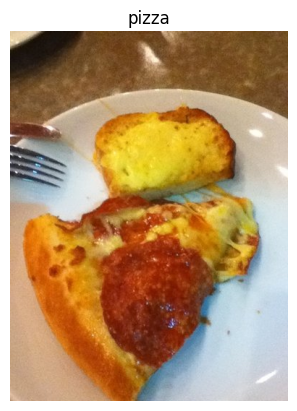

In [10]:
#View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/", target_class="pizza")

In [11]:
img

array([[[224, 202, 163],
        [231, 209, 170],
        [230, 208, 169],
        ...,
        [111,  79,  32],
        [109,  77,  30],
        [109,  77,  30]],

       [[220, 198, 159],
        [227, 205, 166],
        [226, 204, 165],
        ...,
        [113,  81,  34],
        [113,  81,  34],
        [112,  80,  33]],

       [[220, 197, 156],
        [226, 203, 162],
        [225, 202, 161],
        ...,
        [112,  80,  33],
        [114,  82,  35],
        [111,  79,  32]],

       ...,

       [[193, 159, 131],
        [202, 168, 140],
        [209, 175, 147],
        ...,
        [206, 197, 198],
        [204, 195, 196],
        [203, 194, 195]],

       [[186, 153, 122],
        [194, 161, 130],
        [199, 165, 137],
        ...,
        [206, 197, 198],
        [204, 195, 196],
        [202, 193, 194]],

       [[179, 146, 115],
        [185, 152, 121],
        [188, 154, 126],
        ...,
        [205, 196, 197],
        [203, 194, 195],
        [202, 193, 194]]

In [12]:
import tensorflow as tf
tf.constant(img)

c:\Project_1\ml_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


<tf.Tensor: shape=(512, 384, 3), dtype=uint8, numpy=
array([[[224, 202, 163],
        [231, 209, 170],
        [230, 208, 169],
        ...,
        [111,  79,  32],
        [109,  77,  30],
        [109,  77,  30]],

       [[220, 198, 159],
        [227, 205, 166],
        [226, 204, 165],
        ...,
        [113,  81,  34],
        [113,  81,  34],
        [112,  80,  33]],

       [[220, 197, 156],
        [226, 203, 162],
        [225, 202, 161],
        ...,
        [112,  80,  33],
        [114,  82,  35],
        [111,  79,  32]],

       ...,

       [[193, 159, 131],
        [202, 168, 140],
        [209, 175, 147],
        ...,
        [206, 197, 198],
        [204, 195, 196],
        [203, 194, 195]],

       [[186, 153, 122],
        [194, 161, 130],
        [199, 165, 137],
        ...,
        [206, 197, 198],
        [204, 195, 196],
        [202, 193, 194]],

       [[179, 146, 115],
        [185, 152, 121],
        [188, 154, 126],
        ...,
        [205, 196, 19

In [13]:
# View image shape
img.shape  # should be (height, width, color_channels)

(512, 384, 3)

In [14]:
# get all the pixel values between 0 and 1
img = img / 255.0 #normalization or scaling
img

array([[[0.87843137, 0.79215686, 0.63921569],
        [0.90588235, 0.81960784, 0.66666667],
        [0.90196078, 0.81568627, 0.6627451 ],
        ...,
        [0.43529412, 0.30980392, 0.1254902 ],
        [0.42745098, 0.30196078, 0.11764706],
        [0.42745098, 0.30196078, 0.11764706]],

       [[0.8627451 , 0.77647059, 0.62352941],
        [0.89019608, 0.80392157, 0.65098039],
        [0.88627451, 0.8       , 0.64705882],
        ...,
        [0.44313725, 0.31764706, 0.13333333],
        [0.44313725, 0.31764706, 0.13333333],
        [0.43921569, 0.31372549, 0.12941176]],

       [[0.8627451 , 0.77254902, 0.61176471],
        [0.88627451, 0.79607843, 0.63529412],
        [0.88235294, 0.79215686, 0.63137255],
        ...,
        [0.43921569, 0.31372549, 0.12941176],
        [0.44705882, 0.32156863, 0.1372549 ],
        [0.43529412, 0.30980392, 0.1254902 ]],

       ...,

       [[0.75686275, 0.62352941, 0.51372549],
        [0.79215686, 0.65882353, 0.54901961],
        [0.81960784, 0

"Note: As we've discussed before, many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to scale (also referred to as normalize) their pixel values by dividing the image arrays by 255. (since 255 is the maximum pixel value)."

## An end-to-end example

Lets build a convolutional neural network to find patterns in our images, more specifically we need a way to do:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNNN to our training data


In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32, # number of images to process at a time 
                                               target_size=(224, 224), # convert all images to be 224 x 224
                                               class_mode="binary", # type of problem we're working on
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

# Create a CNN model (same as Tiny VGG - https://poloclub.github.io/cnn-explainer/)
model_1 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=10, 
                         kernel_size=3, # can also be (3, 3)
                         activation="relu", 
                         input_shape=(224, 224, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5


c:\Project_1\ml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.6387 - loss: 0.6213 - val_accuracy: 0.6820 - val_loss: 0.5636
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7833 - loss: 0.4749 - val_accuracy: 0.8300 - val_loss: 0.3964
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8120 - loss: 0.4156 - val_accuracy: 0.8620 - val_loss: 0.3361
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8153 - loss: 0.4211 - val_accuracy: 0.8240 - val_loss: 0.3971
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8280 - loss: 0.4111 - val_accuracy: 0.8640 - val_loss: 0.3345


In [16]:
from multiprocessing import pool
from warnings import filters
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Set the seed
tf.random.set_seed(42)

#Preprocess the data (get all of the pixels between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

#Setup paths to our data directories
train_dir  = "C:\\Project_1\\Tensorflow-1\\pizza_steak\\train"
test_dir = "C:\\Project_1\\Tensorflow-1\\pizza_steak\\test"

#Import data from the directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory = 
    train_dir,
    batch_size = 32,
    target_size = (224, 224),
    class_mode = "binary",
    seed = 42)

valid_data = valid_datagen.flow_from_directory(directory = 
    test_dir,
    batch_size = 32,
    target_size = (224, 224),
    class_mode = "binary",
    seed = 42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters = 10, kernel_size = (3, 3), activation = "relu", input_shape = (224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.MaxPool2D(pool_size = 2, padding= "valid"),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

#Compile our CNN
model_1.compile(loss = "binary_crossentropy", 
                optimizer = "adam", 
                metrics = ["accuracy"])
#Fit our model
history_1 = model_1.fit(train_data, 
                        epochs = 5, 
                        steps_per_epoch = len(train_data), 
                        validation_data = (valid_data),
                        validation_steps = len(valid_data))
                        

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.5733 - loss: 0.6768 - val_accuracy: 0.7220 - val_loss: 0.5722
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7167 - loss: 0.5475 - val_accuracy: 0.7400 - val_loss: 0.4995
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7947 - loss: 0.4676 - val_accuracy: 0.8280 - val_loss: 0.3924
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.8013 - loss: 0.4289 - val_accuracy: 0.8240 - val_loss: 0.4086
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8420 - loss: 0.3725 - val_accuracy: 0.8660 - val_loss: 0.3421


In [17]:
# get a model summary
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

### Using the same model as before

Lets replicate the model we've built in a previous section to see if it works with our image data.
the model we're building is from the tensorflow playground: [https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.35726&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false]


In [18]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the tensoflow playground model
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compile the model
model_2.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

#Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5


c:\Project_1\ml_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4933 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4893 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.4787 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4747 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


In [19]:
# get a model summary
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

Despite having 20x more parameters than our CNN model (model_1), model_2 performs terribly... let's try

In [20]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the tensoflow playground model
model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compile the model
model_3.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

#Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.6060 - loss: 3.4449 - val_accuracy: 0.5500 - val_loss: 2.4328
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.6800 - loss: 1.5967 - val_accuracy: 0.7260 - val_loss: 0.9696
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7433 - loss: 0.6419 - val_accuracy: 0.5860 - val_loss: 1.2363
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.7293 - loss: 0.7347 - val_accuracy: 0.7760 - val_loss: 0.4907
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.7447 - loss: 0.5910 - val_accuracy: 0.5040 - val_loss: 1.6137


In [21]:
# get a summary of model_3
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

Note: you can think of trainable parameters as patterns a model learns from data. intuitively, the more trainable parameters a model has, the more patterns it can learn. intuitively, this should lead to better performance, however, too many trainable parameters can lead to overfitting. Intuitively, you might think more is better. And in lots of cases, it is. But in this case, the differences here is the two different styles of model we're using. Where a series of a dense layers has a number of different learnable parameters connected to each other and hence a higher number of possible learnable patterns, a ***convolutional neural network seeks to sort out and learn the most important patterns in an image***. So even though these are less learnable paramenters in our convolutional neural network, these are often more helpful in dechiphering between different ***features*** in an image. 

## Binary classification evaluation metrics - lets break it down

1. Become one with the data (visualize, visualize, vizualize)
2. Preprocess the data (prepared it for our model, the main step here was scaling / normalizing & turning our data into batches)
3. Create a model( start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)


## 1. Become one with the data

['2254705.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 512, 3)
Image min value: 0
Image max value: 255
['3462250.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 512, 3)
Image min value: 0
Image max value: 255


<module 'matplotlib.pyplot' from 'c:\\Project_1\\ml_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

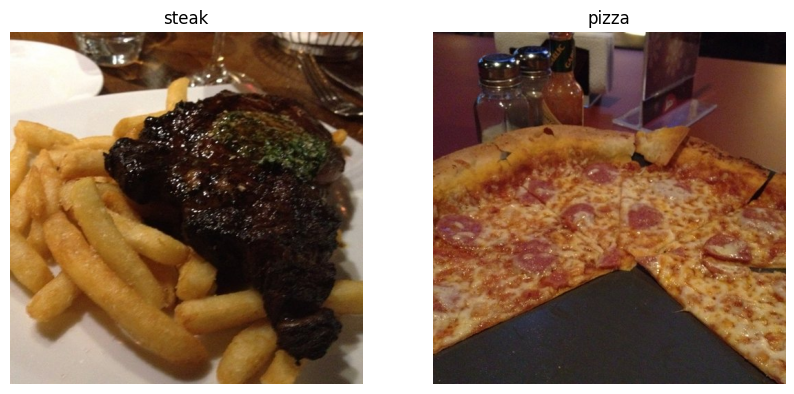

In [22]:
# Visualize data
plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
steak_img = view_random_image(target_dir="pizza_steak/train/", target_class="steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image(target_dir="pizza_steak/train/", target_class="pizza")
plt



### 2 2. Preprocess the data""" (prepare for a model)

In [23]:
# Define directory dataset path
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

### Our nest step is to turn our data into **batches**.

A batch is a group of images that are processed together. This allows us to train the model on multiple. rather than look at all ~10,000 images at one time, a model might only look at 32 at a time. It does this for a couple of reasons:

1. 10,000 images (or more) might not fit into the memory of your processor (GPU)
2. Trying to learn the patterns in 10,000 images in one hit could result in the model not being able to learn very well

Why 32?
Because it's a common batch size used by many machine learning models. It's also a good balance


In [24]:
# Create train and test data generators and rescale the images
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)


In [25]:
# Load data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir, #target directory of the images
                                               batch_size=32, # size of minibatches to load data into
                                                  target_size=(224, 224), # resize all images to 224 x 224
                                                    class_mode="binary", # type of data you're working with
                                                    seed=42)


test_data = test_datagen.flow_from_directory(directory=test_dir,
                                              batch_size=32,    
                                                target_size=(224, 224),
                                                  class_mode="binary",
                                                  seed=42)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [26]:
# get a sample of the train data batch
images, labels = next(train_data) # get next batch of images and labels in train_data
len(images), len(labels)

(32, 32)

In [27]:
# How manybatches are there?
len(train_data), len(test_data) #1500/22=75, 500/32=15.625~16 

(47, 16)

In [28]:
# get the first two images
images[:2], images[0].shape

(array([[[[0.42352945, 0.43137258, 0.34509805],
          [0.3137255 , 0.32941177, 0.2392157 ],
          [0.26666668, 0.28235295, 0.18431373],
          ...,
          [0.42352945, 0.34509805, 0.3803922 ],
          [0.427451  , 0.34901962, 0.39607847],
          [0.45098042, 0.36862746, 0.427451  ]],
 
         [[0.2901961 , 0.30588236, 0.21568629],
          [0.45882356, 0.47450984, 0.37647063],
          [0.2627451 , 0.28627452, 0.18431373],
          ...,
          [0.39607847, 0.34117648, 0.34117648],
          [0.4156863 , 0.36862746, 0.38431376],
          [0.39607847, 0.34901962, 0.3647059 ]],
 
         [[0.3647059 , 0.40000004, 0.29411766],
          [0.38823533, 0.42352945, 0.31764707],
          [0.30588236, 0.34117648, 0.23529413],
          ...,
          [0.34509805, 0.3254902 , 0.30980393],
          [0.30980393, 0.29803923, 0.2784314 ],
          [0.3372549 , 0.3254902 , 0.30588236]],
 
         ...,
 
         [[0.5137255 , 0.5019608 , 0.54509807],
          [0.52156

In [29]:
images[7].shape # 

(224, 224, 3)

In [30]:
# View the firts batch of labels
labels

array([1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1.,
       0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.],
      dtype=float32)

### 3' Create a CNN model to classify pizza vs steak images (start with a baseline)

A baseline is a relatively simpple model or existing result that you setup when beginning a machine learning project and then as you keep experimenting, you compare your results against them to see if you have improved upon them. Baselines are often used as a starting point for more complex models and can serve

**Note** In deep learning, there is almost an infinite amount of architectures you could create. So one of the best ways to get started is to start with something simple and see if it works on your data an then introduce complexity as required (e.g. look at wich current model is performing best in the filed for  your problem).


In [31]:
# Make the creating of our model a little easier by defining constants
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [32]:
# Create the model (this will be our baseline, a layer convolutional neural network)

model_4 = Sequential([
    Conv2D(filters=10, # filter is the number  of sliding windows going accross an input (higher=more complex models)
           kernel_size=(3, 3), # the size of the sliding window going accross the input
           strides=1, # the size of the step the sliding window takes accross an input
           padding='same',  # if "same", output shape is same as input shape, if "valid", outputs shapes get compressed
           activation='relu',
           input_shape=(224, 224, 3)), # input layer (specify the input shape)
    Conv2D(10, 3, activation='relu'),
    Conv2D(10, 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')  # output layer (working on a binary classification problem)
    ])


In [33]:
# Compile the model
model_4.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [34]:
# get a summary of model_4
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 484000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │       484,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,101 (1.85 MB)

 Trainable params: 486,101 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Fit the model

In [35]:
# Check the lenght of training and test data generators
len(train_data), len(test_data)


(47, 16)

In [36]:
# Fit the model
history_4 = model_4.fit(train_data, # this is the combination of labels and sample data
                        epochs=5, # number of times to repeat the training process over all batches in the dataset
                        steps_per_epoch=len(train_data), # number of batches per epoch
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6807 - loss: 0.8491 - val_accuracy: 0.7920 - val_loss: 0.4374
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.8053 - loss: 0.4324 - val_accuracy: 0.8280 - val_loss: 0.3832
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8780 - loss: 0.3250 - val_accuracy: 0.8380 - val_loss: 0.3804
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.9273 - loss: 0.2060 - val_accuracy: 0.8300 - val_loss: 0.3750
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9787 - loss: 0.0842 - val_accuracy: 0.8320 - val_loss: 0.4133


## 5 Evaluate the model on the test data

It looks like our model is learning something, let's evaluate it.

<Axes: >

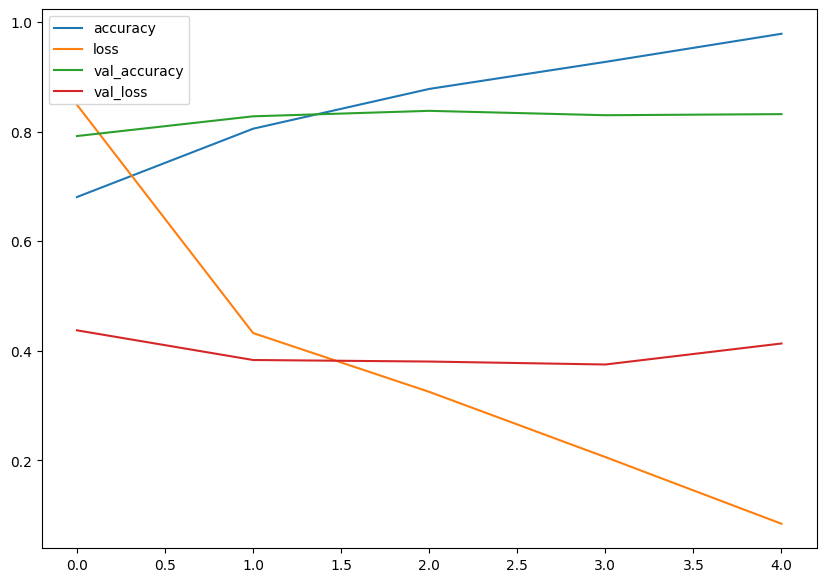

In [37]:
import pandas as pd
# Convert the history object into a pandas DataFrame
pd.DataFrame(history_4.history).plot(figsize=(10, 7))

In [38]:
# Plot the validation and training curves separately
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(history.history['loss']))  # how many epochs did we run for?
    
    plt.figure(figsize=(15, 7))
    # Plot loss
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='training_loss')   
    plt.plot(epochs, val_loss, label='validation_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    # Plot accuracy
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='training_accuracy')
    plt.plot(epochs, val_accuracy, label='validation_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

**Note:** When a model's **validation loss starts to increase**, it's likely that model is **overfitting** the trainning dataset. this means, itsthe model has learned the training data **too well** and thus the model's ability to generalize to unseen data will be diminished.

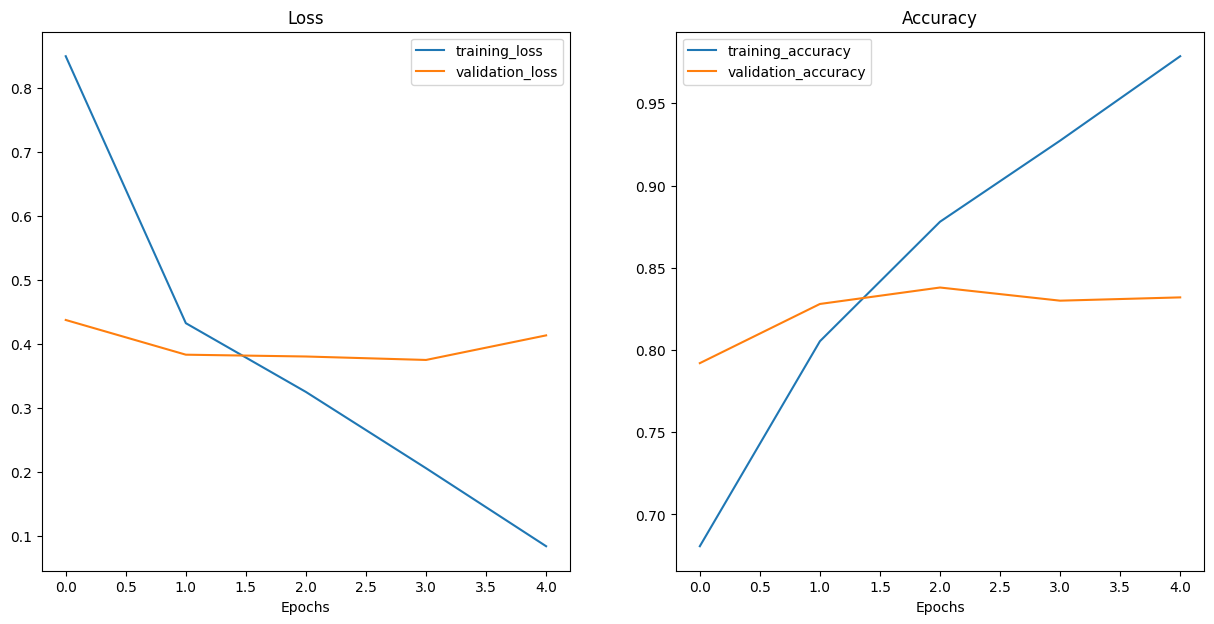

In [39]:
# Check out our loss curves and accuracy curves
plot_loss_curves(history_4)

### 6. adjust the model parameters

Fitting a machine learning model comes in 3 steps:

0. Create a baseline
1. Beat the baseline
2. reduce overfitting

Ways to induce  overfitting: 

* Increase the number of conv layers
* Increase the number of conv filters
* Add another dense layer to the output of our flattened layer

Reduce overfitting:

* Add data augmentation
* Add regularization layers (such as MaxPool2D)
* Add mode data...


**Note:** reducing oferfiting is also know as **regularization**



In [40]:
# Create the  model (this is going to be our baseline, a layer convolutional neural network
model_5 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
    ])

c:\Project_1\ml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# Compile the model
model_5.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [42]:
# Fit the model
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.6593 - loss: 0.6194 - val_accuracy: 0.7280 - val_loss: 0.5102
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7980 - loss: 0.4468 - val_accuracy: 0.8660 - val_loss: 0.3433
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8260 - loss: 0.3956 - val_accuracy: 0.8640 - val_loss: 0.3446
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8487 - loss: 0.3694 - val_accuracy: 0.8580 - val_loss: 0.3233
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8440 - loss: 0.3606 - val_accuracy: 0.8740 - val_loss: 0.3066


In [43]:
# get a summary of model_5
model_5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

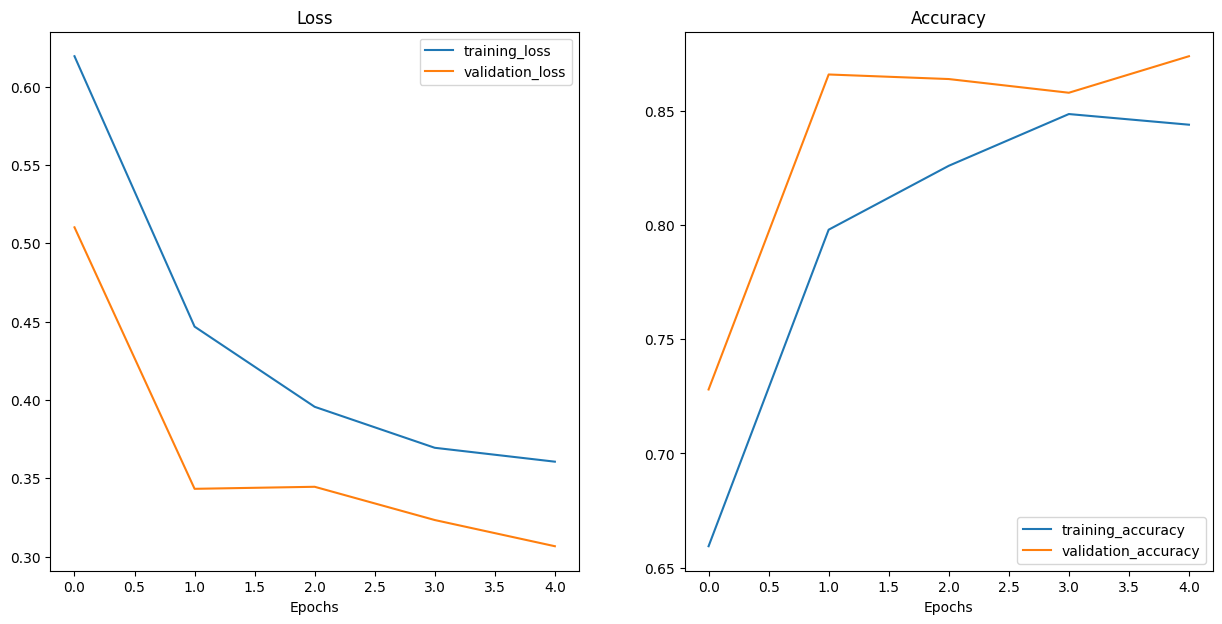

In [44]:
# Plot the loss curves
plot_loss_curves(history_5)

### Opening our bag of tricks and finding data augmentation techniques

In [45]:
# Create ImageDataGenerator instances with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1./255,
                                             rotation_range=0.3, # how much do you want to rotate an image
                                             shear_range=0.2, # shear angle in counter-clockwise direction
                                             zoom_range=0.2, #  zoom in and out
                                             width_shift_range=0.2, # move the image left or right
                                             height_shift_range=0.2, # move the image up and down
                                             horizontal_flip=True) # flip the image horizontally
                                             # vertical_flip=True) # flip the image vertically

# Create ImageDataGenerator without data augmentation
train_datagen = ImageDataGenerator(rescale=1./255)

#Create ImageDataGenerator without data augmentation for the test  dataset
test_datagen = ImageDataGenerator(rescale=1./255)


***Question***: What is data augmentation?
Data augmentation is the process of altering our training data, leading it ot have more diversity and it turn allowing our models to learn more generalizable (hopefully) patterns.
Altering might mean adjusting the rotation of an image, flipping it, cropping it or something similar.

Let's write some code to visualize data augmentation...

In [46]:
# Import data and augment it from trainning directory
from random import shuffle


print("Augmented training data:")
train_datagen_augmented.flow_from_directory(train_dir,
                                            batch_size=32,
                                            target_size=(224, 224),
                                            class_mode="binary",
                                            shuffle=False) # For demonstration only

# Create non-augmented train data batches
print("Non-augmented training data:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               class_mode="binary",
                                               shuffle=False)
IMG_SIZE  = (224, 224)
# Create non-augmented test data batches
print("Non-augmented test data:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMG_SIZE,
                                             batch_size=32,
                                             class_mode="binary",)

Augmented training data:
Found 1500 images belonging to 2 classes.
Non-augmented training data:
Found 1500 images belonging to 2 classes.
Non-augmented test data:
Found 500 images belonging to 2 classes.


**Note** Data augmentation is usually only performed on the trainning set. Using ImageageDataGenerator built-in data augmentation parameters our images are left as they are in the directories but are modified as they're loaded into the model.

Finally... let's visualiza some augmented data!!!

In [47]:
# get sample data batches
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_datagen_augmented.flow_from_directory(train_dir,
																						batch_size=32,
																						target_size=(224, 224),
																						class_mode="binary",
																						shuffle=False)) # note: labels aren't augmented... only data (images)


Found 1500 images belonging to 2 classes.


showing image number: 17


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

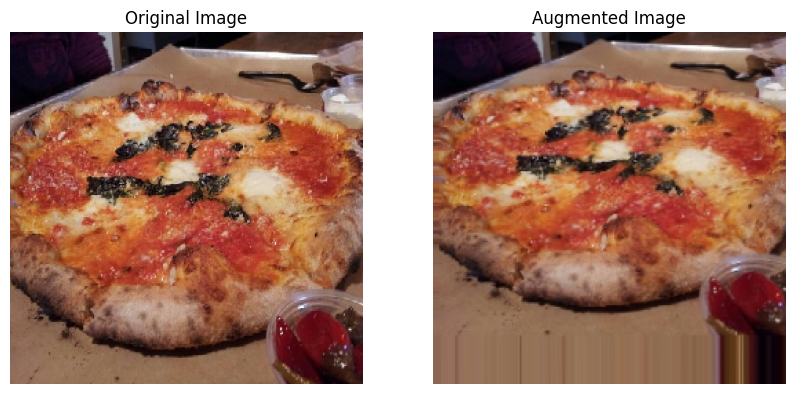

In [48]:
# Show original and augmented images
random_number = random.randint(0, 32) # our batch sizes are 32...
print(f"showing image number: {random_number}")
plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
plt.imshow(images[random_number])
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(augmented_images[random_number])
plt.title("Augmented Image")
plt.axis("off")


Now we've seen what augmented training data looks like, let's build a model and see how it learns on augmented data

In [49]:
# Create a model (same as model_5)
model_6 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
    ])

In [2]:
help(Sequential)

NameError: name 'Sequential' is not defined